# Aula 17 - Introdução ao Aprendizado Supervisionado: Classificação

Nesta aula vamos estudar o uso de algoritmos de **Aprendizado de Máquina Supervisionado**. Focaremos nos algoritmos utilizados para **classificação**, que é a tarefa de predizer classes (rótulos categóricos) para conjuntos de dados (numéricos ou transformados em numéricos).

Existem muitos algoritmos para se realizar essa tarefa, entre eles:
- Regressão Logística
- Análise de Discriminante Linear (LDA)
- Análise de Discriminante Quadrático (QDA)
- Naive Bayes
- k-vizinhos mais próximos (KNN)
- Máquina de Vetor Suporte (SVM)
- Árvore de Decisão
- RandomForest

Cada uma dessas técnicas tem uma forte base matemática e conceitual. Os algoritmos foram propostos ao longo de diversas décadas e possuem diferentes cenários de aplicações. Não teremos tempo de ver cada um deles a fundo, nem mesmo todos eles. Iremos nos focar nos procedimentos básicos para se utilizar esses algoritmos.

--------------------------

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Exemplo 1 - Entomologia: Gafanhatos vs Esperanças

Foram medidos o comprimento das antenas e do abdômen de dois tipos de insetos: gafanhotos e esperanças.


### Exemplo 1 - Primeiro passo: carregar os dados e fazer Análise Exploratória

Como já fizemos a Análise Exploratória com esses dados na outras aulas, iremos pular essa etapa.

In [6]:
# Para trabalhar com dados em tabelas
import pandas as pd

# Para trabalhar com gráficos
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
path_gaf_esp =  "/content/drive/MyDrive/Colab Notebooks/gaf_esp (1).csv"

In [8]:
dados = pd.read_csv(path_gaf_esp, sep=';') # Estamos carregando o arquivo csv usando o ; como separador

In [9]:
dados.head()

,Espécie,Comprimento do Abdômen,Comprimento das Antenas
0,Gafanhoto,0.50,7.0
1,Gafanhoto,0.50,6.0
2,Gafanhoto,0.60,5.5
3,Gafanhoto,0.65,4.5
4,Gafanhoto,0.54,3.2


In [12]:
dados.shape

(100, 3)

In [14]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Espécie                  100 non-null    object 
 1   Comprimento do Abdômen   100 non-null    float64
 2   Comprimento das Antenas  100 non-null    float64
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [16]:
dados['Espécie'].value_counts()

,count
Espécie,
Gafanhoto,50
Esperança,50


In [29]:
dados["Comprimento do Abdômen"].mean(), dados["Comprimento das Antenas"].mean()

(np.float64(4.9362), np.float64(5.382400000000001))

In [ ]:
dados[dados["Espécie"] == "Gafanhoto"]["Comprimento das Antenas"].mean()

In [ ]:
dados[dados["Espécie"] == "Esperança"]["Comprimento das Antenas"].mean()

In [19]:
dados['Espécie'] == "Gafanhoto"

,Espécie
0,True
1,True
2,True
3,True
4,True
...,...
95,False
96,False
97,False
98,False


In [23]:
(
dados[dados['Espécie'] == "Gafanhoto"]["Comprimento do Abdômen","Comprimento das Antenas"].mean()
)

KeyError: ('Comprimento do Abdômen', 'Comprimento das Antenas')

In [24]:
meus_dados = {
    "id": [1, 2, 3, 4, 5],
    'nome': ['João', 'Maria', 'José', 'Ana', 'Pedro'],
    'idade': [25, 30, 35, 40, 45],
}

In [26]:
pd.DataFrame(meus_dados)

,id,nome,idade
0,1,João,25
1,2,Maria,30
2,3,José,35
3,4,Ana,40
4,5,Pedro,45


In [28]:
pd.DataFrame([{1,2,3,4}])

,0,1,2,3
0,1,2,3,4


In [30]:
dados["Comprimento do Abdômen"].median(), dados["Comprimento das Antenas"].median()

(4.5, 5.5)

In [31]:
dados.groupby("Espécie").mean()

,Comprimento do Abdômen,Comprimento das Antenas
Espécie,,
Esperança,8.1206,7.2156
Gafanhoto,1.7518,3.5492


In [32]:
dados.colums = dados.columns.str.replace(" ", "_")

/tmp/ipykernel_4895/3116624980.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dados.colums = dados.columns.str.replace(" ", "_")


In [33]:
dados.columns = dados.columns.str.replace(" ", "_")

In [ ]:
new_columns = [
    new_name.replace(' ', '_').lower()
    for new_name in dados.columns
    ]

In [ ]:
new_columns

In [ ]:
dados.columns

In [ ]:
dados.columns = new_columns

In [ ]:
def funcao(x):
    return x.replace(" ", "_").lower()

In [36]:
dados.columns = dados.apply(lambda x: str.lower(x.name.replace(" ", "_")))

In [37]:
dados

,espécie,comprimento_do_abdômen,comprimento_das_antenas
0,Gafanhoto,0.50,7.0
1,Gafanhoto,0.50,6.0
2,Gafanhoto,0.60,5.5
3,Gafanhoto,0.65,4.5
4,Gafanhoto,0.54,3.2
...,...,...,...
95,Esperança,9.75,6.2
96,Esperança,6.20,8.1
97,Esperança,9.20,4.7
98,Esperança,9.10,6.0


In [ ]:
dados = dados[["comprimento_do_abdômen", "comprimento_das_antenas", "espécie"]]
dados.head()

### Exemplo 1 - Segundo passo: separar os dados

Precisamos ter claro em nossas mentes quais são os atributos (colunas) preditivas, isto é, aquelas que usaremos para predizer um atributo alvo (coluna alvo). No nosso caso os **atributos preditivos são Comprimento do Abdômen e Comprimento das Antenas**, e o **atributo alvo é a Espécie** que será predita.

Quando se trabalhar com Aprendizado de Máquina Supervisionado, além disso precisamos separar nossos dados em dois conjuntos: um **conjunto de treinamento** e um **conjunto de teste**. Fazemos isso para evitar overfitting do algoritmo.

Existem várias estratégias para se separar dados. Vamos aplicar as principais:

(a) Escolher o tamanho dos conjuntos - 80% para treinamento e 20% para teste;

(b) Selecionar aleatoriamente os dados que irão compor o conjunto de treinamento e teste (usando um seed para garantir reprodutibilidade);

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
x = dados.drop(columns = 'espécie')

In [49]:
y = dados['espécie']
y.head()

,espécie
0,Gafanhoto
1,Gafanhoto
2,Gafanhoto
3,Gafanhoto
4,Gafanhoto


In [50]:
# Dividindo conjunto de treinamento e conjunto de teste
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42)

In [51]:
x_train.head(5)

,comprimento_do_abdômen,comprimento_das_antenas
55,9.50,5.5
88,6.54,9.0
26,2.60,4.3
42,2.78,3.6
69,8.00,7.0


In [52]:
y_train.head(5)

,espécie
55,Esperança
88,Esperança
26,Gafanhoto
42,Gafanhoto
69,Esperança


### Exemplo 1 - Terceiro passo: transformar os dados

Dependendo do algoritmo de Aprendizado de Máquina que usamos precisamos modificar os dados para que eles se adequem as premissas do algoritmo.

Existem duas transformações de escalonamento muito utilizadas:

1) **Nomalização** (Normalization) - Também conhecido como escalonamento Min-Max no qual o range de valores da coluna irá fica de 0 (min) até 1 (max);

2) **Padronização** (Standardization) - Modifica a distribuição para que a média seja igual a zero e desvio padrão igual a 1 (o método subtrai a média de todas as entradas e dividide pelo desvio padrão);

Quando escolher uma ou outra? Depende dos seus dados, seu problema e o algoritmo que você quer usar. Em alguns casos, escalonar ou não os dados não irá mudar a solução do problema! Ao longo do cursos iremos estudar alguns casos...

**IMPORTANTE**: independentmente do transformador escolhido, ele deve ser fitado apenas sobre os dados de treinamento. Isto é, o treinamento do escalonador deve receber apenas os dados de treinamento x_train. Após o treinamento do escalonador, ele deverá ser usado para transformar os dados x_test também.

In [ ]:
# Vamos pular essa etapa para deixar o exemplo mais simples nesse primeiro momento

### Exemplo 1 - Quarto passo: treinar o algoritmo

Vamos usar o conjunto de treinamento para treinar o algoritmo escolhido.

Existem vários algoritmos possíveis. Cada algoritmo tem seus **hiperparâmetros** (parâmetros que devem ser escolhidos para melhorar a performance do algoritmo). Para entender os hiperparâmetros de cada algoritmo é necessário entender a fundo como aquele algoritmo funciona.

Aqui vamos usar um dos algoritmos mais simples existentes, o Descriminador Linear:

In [42]:
import pickle
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [53]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()  # Criamos o objeto do classificador (não mudamos nenhum hiperpârametro)

lda.fit(x_train, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

LinearDiscriminantAnalysis()

In [54]:
filename = 'finalized_model.pkl'
pickle.dump(lda, open(filename, 'wb'))

### <font color='red'>Como sabemos se o algoritmo está bom?</font>

### Exemplo 1 - Quinto passo: testar e avaliar

Usando agora o conjunto de teste, iremos testar o classificador criado e treinando no passo anterior.

Uma vez que realizamos um teste, precisamos avaliar o desempenho do nosso método. Diferentes hiperparâmetros e diferentes algoritmos podem ter um desempenho diferente. Apesar de sempre buscarmos o melhor desempenho, devemos levar em consideração outros aspectos para decidir o que é um desempenho aceitável. A primeira coisa a definir são as **métricas de desempenho** que podem ser comparadas entre diferentes algoritmos.

Existem várias métricas para se medir o desempenho de um classificador: métricas de performance, métricas de tempo consumido, métricas de memória consumida, etc. Vamos focar em uma métrica de performance muito utilizada no dia a dia de trabalho: a **Matriz de Confusão** e seus índices (**Acurácia, Precisão, Recall e F1-score**).

In [55]:
x_test.head()

,comprimento_do_abdômen,comprimento_das_antenas
83,8.74,6.20
53,5.40,8.50
70,7.00,8.00
45,2.37,3.76
44,2.42,3.89


In [56]:
y_test.head()

,espécie
83,Esperança
53,Esperança
70,Esperança
45,Gafanhoto
44,Gafanhoto


In [58]:
# Perceba que estamos passando apenas o x de teste,
# afinal o algoritmo é que nos dira qual é o y
y_predicoes = lda.predict(x_test)

In [59]:
y_predicoes

array(['Esperança', 'Esperança', 'Esperança', 'Gafanhoto', 'Gafanhoto',
       'Gafanhoto', 'Gafanhoto', 'Esperança', 'Gafanhoto', 'Gafanhoto',
       'Gafanhoto', 'Gafanhoto', 'Esperança', 'Gafanhoto', 'Esperança',
       'Gafanhoto', 'Esperança', 'Esperança', 'Gafanhoto', 'Gafanhoto'],
      dtype='<U9')

In [63]:
## dados_pred = x_teste.copy()

NameError: name 'x_teste' is not defined

In [62]:
## dados_pred["esperado"] = y_test
## dados_pred["predicao"] = y_predicoes

NameError: name 'dados_pred' is not defined

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay#, plot_confusion_matrix
from sklearn.metrics import (f1_score
                             , accuracy_score
                             , precision_score
                             , recall_score
                             , classification_report)

In [65]:
matriz_confusao = confusion_matrix(y_true = y_test,
                                   y_pred = y_predicoes,
                                   labels=['Gafanhoto','Esperança'])

<Figure size 1500x500 with 0 Axes>

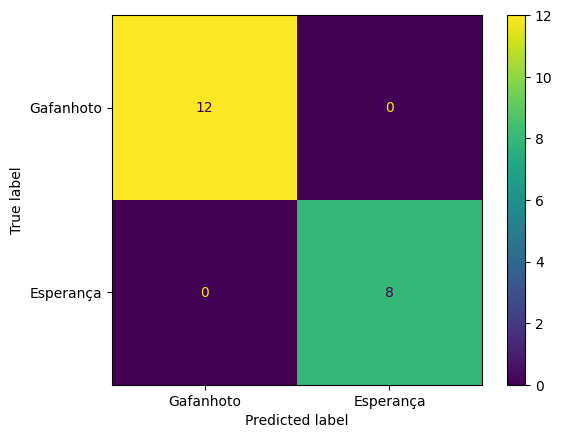

In [66]:
# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = matriz_confusao
    , display_labels=['Gafanhoto','Esperança'])

disp.plot(values_format='d')

In [ ]:
accuracy_score(y_true = y_test, y_pred = y_predicoes)

In [ ]:
precision_score(y_true = y_test,
         y_pred = y_predicoes,
         pos_label="Esperança")

In [ ]:
recall_score(y_true = y_test,
         y_pred = y_predicoes,
         pos_label="Esperança")

In [ ]:
f1_score(y_true = y_test,
         y_pred = y_predicoes,
         pos_label="Esperança")

In [ ]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

Vamos desenhar sobre o gráfico de dispersão o modelo matemático encontrado pelo algoritmo de Classificação LDA:

In [ ]:
import numpy as np

In [ ]:
dados

In [ ]:
lda.coef_

In [ ]:
# São os coeficientes do nosso modelo de ML treinado
c1, c2 = lda.coef_[0]

In [ ]:
c1, c2

In [ ]:
b = lda.intercept_
b

In [ ]:
# É a equação da reta do LDA
x1 = np.arange(0, 10)
x1

In [ ]:
x2 = - (c1/c2)* x1 - b/c2

In [ ]:
x3 = - ((c1/c2) * x1 + b/c2)
x4 = (-c1*x1-b)/(c2)

In [ ]:
- c2 * x1

In [ ]:
(- c1 * x1 - b)/c2

In [ ]:
x3

In [ ]:
x4

A fronteira de decisão entre as classes em um classificador LDA é uma linha.

Toda linha tem uma função metamática associada.

Podemos ver os coeficientes dessa fronteira (hiperplano ou linhas) na propriedade `coef_`.

Para um problema de duas dimensões, (como o acima), temos dois coeficientes. Vamos chamar esses coeficientes de $c_1$ e $c_2$, e os atributos de $x_1$ e $x_2$, e o valor de interceptação no eixo das ordenadas de $b$. Dessa maneira, temos a equação da fronteira:  

$$ c_1 x_1 + c_2 x_2  + b = 0  $$

Agora, resolvendo para $x_2$, podemos obter a equação da reta:

$$ x_2 =  -\frac{c_1}{c_2}x_1 - \frac{b}{c_2} $$

$$ c_1x_1 + c_2 x_2  + b = 0  $$

Podemos subtrair $$ c_1x_1 $$ dos dois lados

$$ c_2x_2 + b = - c_1x_1 $$

Podemos subtrair $ b $ dos dois lados

$$ c_2x_2 = -c_1x_1 - b $$

E chegamos na nossa equação:

$$ x_2 = \frac{-c_1x_1 - b}{c_2} $$

In [ ]:
plot = sns.jointplot(data=dados, x="comprimento_do_abdômen", y="comprimento_das_antenas", hue = 'espécie',
              height=5, ratio=2, marginal_ticks=True
             )
plot.ax_joint.plot(x1, x4, 'r-', linewidth = 2)
plot.ax_marg_x.axvline(x=4.5, color='k', linestyle='--')
plot.ax_marg_y.axhline(y=5.3, color='k', linestyle='--')
# plot.ax_joint.set_xlim(0, 11)
# plot.ax_joint.set_ylim(0, 11)

### Exemplo 1 - Sexto passo: Produção

Se nosso algoritmo está bom e atende os requisitos de negócio, podemos colocar ele em produção. Essa etapa envolve conhecimento do tipo de dispositivo em que iremos rodar a solução.

Por exemplo, iremos colocar esse modelo em um site? Precisamos trabalhar com o pessoal de backend.
Vamos embarcar em um veículo autônomo? Time de engenharia de software e engenharia eletrônica.

Esse passo inteiro transcede o escopo da nossa disciplina, já que envolve outras disciplinas e competências.

Vamos contudo ver como "baixar" nosso modelo pronto para não precisar treina-lo novamente. Afinal, iremos empregar o algoritmo já treinado e pronto para uso em produção (a menos que estejamos usando técnicas mais sofisticadas de machine learning como Active Learning e Atualização de Modelo em Execução).

A etapa de "salvar/baixar" o modelo pronto é chamada de **Persistência do Modelo**.  Quando usamos um modelo pronto, é comum dizer que estamos usando um **modelo pré-treinado**.

In [ ]:
import pickle

Pickle é um formato de arquivo de objeto python serializado na memória permanente. Ele é análogo ao JSON para dicionários ou o CSV para tabelas, mas ele funciona para objetos python, ou seja, é muito mais abrangente!

In [ ]:
# vamos salvar em bytes (flag wb) para ser mais cross-platform (acessível a vários sistemas)
with open('meu_modelo_serializado.pickle', 'wb') as f:
    pickle.dump(lda, f)

Pronto! Nosso modelo está salvo. Se quisermos usá-lo em um código em Python, podemos simplesmente carregá-lo:

In [ ]:
with open('/content/meu_modelo_serializado.pickle', 'rb') as f:
    modelo_carregado = pickle.load(f)

In [ ]:
modelo_carregado.predict([[4, 2]])

#Proposta de atividade

### Tentar aplicar o LDA no mesmo dataset utilizado no CP1


##### Parada no slide 11


Além do Pickle, o Scikit-Learn tem o método joblib que é mais eficiente para serializar modelos treinados através dessa biblioteca. Vejamos como usar esse formato de arquivo:

In [1]:
from joblib import dump, load

In [3]:
dump(lda, 'meu_modelo_serializado.joblib')

NameError: name 'lda' is not defined

In [35]:
modelo_carregado2 = load('meu_modelo_serializado.joblib')

FileNotFoundError: [Errno 2] No such file or directory: 'meu_modelo_serializado.joblib'

In [ ]:
modelo_carregado2.predict([[1,2]])

----------------------
## Exemplo 2 - Botânica: Íris Dataset

Esse dataset contém medidas da largura e comprimento da pétala e da sépala de **150 amostras** de flores, assim como a espécie de cada uma (*versicolor*, *setosa*, *virginica*). Mais informações: https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html.

<img src="https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png" alt="dieta" width="600px">

Carregando e arrumando os dados como na Aula 15 sobre as flores Íris:

Vamos realizar os mesmos procedimentos do Exemplo 1:

### Exemplo 1 - Primeiro passo: Análise Exploratória

In [ ]:
from sklearn import datasets # Para carregar dataset pronto no scikit-learn
import pandas as pd # Para trabalhar com dados em tabelas

# Para trabalhar com gráficos
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregando os dados
iris = datasets.load_iris()

dados = pd.DataFrame(data=iris.data,  # Estamos dizendo que o dados do dataframe são o atributo data do objeto iris
                     columns = iris.feature_names) # Já o nome das colunas do dataframe serão o atrib feature_names

In [ ]:
iris

In [ ]:
iris.target_names[-1]

In [ ]:
# Aqui estamos criando uma funcao que recebe o número da classe e retorna o nome correspondente
def mapear_nomes(numero_classe):
    return(iris.target_names[numero_classe])

In [ ]:
dados['flower'] = iris.target
dados['flower_name'] = dados['flower'].apply(mapear_nomes)

In [ ]:
dados.head()

In [ ]:
sns.pairplot(dados.drop(columns=['flower']), hue='flower_name')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5), dpi=80)

sns.histplot(ax=axes[0][0],
            data=dados,  # Perceba que estamos passando a coluna o dataframe completo
            x = dados['sepal length (cm)'], # E aqui estamos selecionando a coluna
            kde=True,
            bins=20,
            linewidth=0.7,
            hue = dados['flower_name'],
            palette=["g", "r", "b"]
            )

sns.histplot(ax=axes[0][1],
            data=dados,
            palette=["g", "r", "b"],
            x = dados['sepal width (cm)'],
            kde=True,
            bins=20,
            linewidth=0.7,
            hue = dados['flower_name']
            )

sns.histplot(ax=axes[1][0],
            data=dados,  # Perceba que estamos passando a coluna o dataframe completo
            x = dados['petal length (cm)'], # E aqui estamos selecionando a coluna
            kde=True,
            bins=20,
            linewidth=0.7,
            hue = dados['flower_name'],
            palette=["g", "r", "b"]
            )

sns.histplot(ax=axes[1][1],
            data=dados,
            palette=["g", "r", "b"],
            x = dados['petal width (cm)'],
            kde=True,
            bins=20,
            linewidth=0.7,
            hue = dados['flower_name']
            )

plt.subplots_adjust(wspace=0.2, hspace=0.4)

In [ ]:
import matplotlib.pyplot as plt

# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401

from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(iris.data)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=iris.target,
    s=40,
)

ax.set(
    title="First three PCA dimensions",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
    zlabel="3rd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    iris.target_names.tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

### Exemplo 2 - Segundo passo: separar os dados

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Escolhendo as colunas preditivas e alvo
x = dados.drop(columns = ['flower', 'flower_name']) # Somente Comprimento do Abdômen e Comprimento das Antenas
y = dados['flower_name']                # Classe alvo

# Dividindo conjunto de treinamento e conjunto de teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.80, random_state = 8)

In [ ]:
x.shape

In [ ]:
x_train.head(3)

In [ ]:
y.shape

In [ ]:
x_train.shape, x_test.shape

In [ ]:
max = x_train["sepal width (cm)"].max()
min = x_train["sepal width (cm)"].min()

In [ ]:
max, min

In [ ]:
one_value = x_train["sepal width (cm)"].iloc[0]

In [ ]:
one_value

In [ ]:
(one_value - min) / (max - min)

### Exemplo 2 - Terceiro passo: transformar os dados

Para mais informações sobre tipos de escalonamento, consulte:
https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
# Instanciando o Escalonador
#scaler = StandardScaler()
scaler = MinMaxScaler()

# Treinando o escalonador
scaler.fit(x_train)

# Usando o escalonador treinado para transformar os dados
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
x_test_scaled

In [ ]:
# StandardScaler Method

In [ ]:
mean_var = dados["sepal length (cm)"].mean()

In [ ]:
dados["diff_mean"] = dados["sepal length (cm)"] - mean_var
dados["square"] = dados["diff_mean"] ** 2
desvio_padrao = np.sqrt(dados["square"].sum() / dados.shape[0])

In [ ]:
dados["standardscaler"] = (dados["sepal length (cm)"] - mean_var) / desvio_padrao

In [ ]:
scaler = StandardScaler()
scaler.fit(dados["sepal length (cm)"].to_frame())
scaler.transform(dados["sepal length (cm)"].to_frame())

In [ ]:
dados

In [ ]:
max = dados["sepal width (cm)"].max()
min = dados["sepal width (cm)"].min()

In [ ]:
dados["min_max_scaler"] = (dados["sepal width (cm)"] - min) / (max - min)

In [ ]:
dados

In [ ]:
scaler = MinMaxScaler()
scaler.fit(dados["sepal width (cm)"].to_frame())
scaler.transform(dados["sepal width (cm)"].to_frame())

### Exemplo 2 - Quarto passo: treinar o algoritmo

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay#, plot_confusion_matrix
from sklearn.metrics import (f1_score
                             , accuracy_score
                             , precision_score
                             , recall_score
                             , classification_report
                             , cohen_kappa_score)

In [ ]:
lda = LinearDiscriminantAnalysis()  # Criamos o objeto do classificador (não mudamos nenhum hiperpârametro)

lda.fit(x_train, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

### Exemplo 2 - Quinto passo: testar e avaliar

In [ ]:
dados.head()

In [ ]:
lda.coef_

In [ ]:
lda.intercept_

In [ ]:
# Perceba que estamos passando apenas o x de teste, afinal o algoritmo é que nos dira qual é o y
y_predicoes = lda.predict(x_test)

In [ ]:
y_predicoes

In [ ]:
matriz_confusao = confusion_matrix(y_true = y_test,
                                   y_pred = y_predicoes,
                                   labels=iris.target_names)

# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=iris.target_names)
disp.plot(values_format='d')

In [ ]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

In [ ]:
# Métrica do Coeficiente Kappa de Cohen
cohen_kappa_score(y_test, y_predicoes)

In [ ]:
lda.coef_

------------------
## <font color='red'> Atenção</fonte>:

A seguir são apresentados dois exemplos com datasets de pessoas reais.

Ao se trabalhar com dados de pessoas devemos considerar a origem e os preceitos **bioéticos** envolvidos em sua coleta, construção e utilização.

Além disso, é boa prática que os dados estejam anonimizados.

----------------------
## Exemplo 3 - Diagnóstico médico: Problemas Ortopédicos na Coluna Vertebral

Esse dataset contém dados sobre problemas ortopédicos na coluna vertebral, diagnosticados no Centre Médico-Chirurgical de Réadaptation des Massues, em Lyon, France. Contém 6 atributos biomecânicos para 310 entradas anonimizadas, sendo 100 de pacientes considerados sem problemas (Normal - NO), 60 de pacientes com Hérnia de Disco (Disk Hernia - DH) e 150 de pacientes com Espondilolistese (Spondylolisthesis - SL).

O dataset está disponível em https://www.openml.org/d/1523


![image-8.png](attachment:image-8.png)

### Exemplo 3 - Primeiro passo: Carregar dados e Realizar a Análise Exploratória

Para importar dados do OpenML podemos usar uma função pronta na biblioteca do Scikit-Learn:

In [ ]:
 A B C

 C B A

 B C A

 A C B

C A B

In [ ]:
import numpy as np

In [ ]:
n = 70
1 -(np.math.factorial(365) / ((365 ** n)* np.math.factorial(365 - n)))

In [ ]:
n = 60
p = 6
C = np.math.factorial(n) / (np.math.factorial(p) * np.math.factorial(n - p))
print(C, 1 / C)

In [ ]:
from sklearn.datasets import fetch_openml

In [ ]:
fetch_openml

In [ ]:
dados = fetch_openml(data_id=1523)

Perceba que o tipo do dado continua sendo um objeto Bunch, como vimos na aula 15.

In [ ]:
dados

In [ ]:
type("texto")

Agora que temos os dados carregamos em memória, podemos transformá-lo em um Dataframe do pandas:

In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame(dados.data, columns=dados.feature_names)

In [ ]:
df.head()

Vamos adicionar a coluna de target na frente.

Perceba, entretanto, que o atributo target_names do Bunch dados não nos é útil. Vamos precisar encontrar o diagnóstico representado por cada número de outra forma. Por sorte, temos a informação de quantas entradas são para cada classe e podemos usar isso para mapear os nomes corretos:

In [ ]:
dados.target_names

In [ ]:
list(dados.target).count('1')

In [ ]:
dados.target

In [ ]:
list(dados.target).count('2')

In [ ]:
list(dados.target).count('3')

In [ ]:
target_map={
    '1':'Disk Hernia',
    '2':'Normal',
    '3':'Spondylolisthesis'
}

In [ ]:
df['diagnostic'] = [target_map[target] for target in dados.target]

In [ ]:
df.head(3)

Vamos gerar algumas estatísticas e visualizações exploratórias dos dados:

In [ ]:
import seaborn as sns

In [ ]:
import seaborn as sns
sns.pairplot(df, hue='diagnostic')

In [ ]:
df.groupby('diagnostic').mean()

In [ ]:
df.groupby('diagnostic').std()

### Exemplo 3 - Segundo passo: separar os dados

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
import seaborn as sns
sns.pairplot(df, hue='diagnostic')


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Escolhendo as colunas preditivas e alvo
x = df.drop(columns = ['diagnostic']) # Somente Comprimento do Abdômen e Comprimento das Antenas
y = df['diagnostic']                # Classe alvo

# Dividindo conjunto de treinamento e conjunto de teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 8)

### Exemplos 3 - Terceiro passo: transformar dados

In [ ]:
# Instanciando o Escalonador
#scaler = StandardScaler()
scaler = MinMaxScaler()

# Treinando o escalonador
scaler.fit(x_train)

# Usando o escalonador treinado para transformar os dados
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Exemplo 3 - Quarto passo: treinar o algoritmo

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
lda = LinearDiscriminantAnalysis()  # Criamos o objeto do classificador (não mudamos nenhum hiperpârametro)

lda.fit(x_train_scaled, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

### Exemplo 3 - Quinto passo: testar e avaliar

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report

In [ ]:
# Perceba que estamos passando apenas o x de teste, afinal o algoritmo é que nos dira qual é o y
y_predicoes = lda.predict(x_test_scaled)

In [ ]:
matriz_confusao = confusion_matrix(y_true = y_test,
                                   y_pred = y_predicoes,
                                   labels=['Disk Hernia','Normal','Spondylolisthesis'])

# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao,
                              display_labels=['Disk Hernia','Normal','Spondylolisthesis'])
disp.plot(values_format='d')

In [ ]:
13 / (13 + 6)

In [ ]:
31 / (31 + 6)

In [ ]:
31 / (31 + 3)

In [ ]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

In [ ]:
# Métrica do Coeficiente Kappa de Cohen
cohen_kappa_score(y_test, y_predicoes)

Obtivemos, no geral, uma acurácia baixa.

Além disso nosso Recall em relação a Hérnia de Disco é muito baixo (temos muitos falsos negativos - pacientes que não tem hérnia de disco classificados com hérnia de disco);

Nossa precisão para Normal também está baixa (temos muito falsos positivos - pacientes classificados como normal mas que tem algum problema);

Precisamos voltar ao **Passo 4** e mexer nos hiperparâmetros do nosso algoritmo ou escolher outro algoritmo de classificação. Vejamos outros algoritmos:

### Exemplo 3 - De volta ao passo 4:

In [ ]:
# Naive Bayes Gaussiano
from sklearn.naive_bayes import GaussianNB

# Passo 4 - Treinar o Classificador
gnb = GaussianNB()  # Criamos o objeto do classificador (não mudamos nenhum hiperpârametro)
gnb.fit(x_train, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

# Passo 5 - Testar o Classificador
y_predicoes = gnb.predict(x_test)

# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

In [ ]:
# k-vizinhos mais próximos (KNN)
from sklearn.neighbors import KNeighborsClassifier

# Passo 4 - Treinar o Classificador
knn = KNeighborsClassifier() # Criando classificador (sem nenhum hiperparametro)
knn.fit(x_train, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

# Passo 5 - Testar o Classificador
y_predicoes = knn.predict(x_test)

# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
X = iris.data[["sepal length (cm)", "sepal width (cm)"]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=15))]
)

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

_, axs = plt.subplots(ncols=2, figsize=(12, 5))

for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X_train, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )

plt.show()

In [ ]:
# Árvore de Decisão
from sklearn.tree import DecisionTreeClassifier

# Passo 4 - Treinar o Classificador
dtree = DecisionTreeClassifier() # Criando classificador (sem nenhum hiperparametro)
dtree.fit(x_train, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

# Passo 5 - Testar o Classificador
y_predicoes = dtree.predict(x_test)

# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

In [ ]:
# RandomForest
from sklearn.ensemble import RandomForestClassifier

# Passo 4 - Treinar o Classificador
rf = RandomForestClassifier(random_state=42) # Criando classificador (hiperparametro de seed)
rf.fit(x_train, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

# Passo 5 - Testar o Classificador
y_predicoes = rf.predict(x_test)

# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

In [ ]:
# Máquina de Vetor Suporte
from sklearn.svm import SVC

# Passo 4 - Treinar o Classificador
svm = SVC() # Criando classificador (sem nenhum hiperparametro)
svm.fit(x_train, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

# Passo 5 - Testar o Classificador
y_predicoes = svm.predict(x_test)

# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

In [ ]:
# Regressão Logística
from sklearn.linear_model import LogisticRegression

# Passo 4 - Treinar o Classificador
logreg = LogisticRegression() # Criando classificador (sem nenhum hiperparametro)
logreg.fit(x_train, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

# Passo 5 - Testar o Classificador
y_predicoes = logreg.predict(x_test)

# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

Nós testamos diferentes algoritmos de classificação.

Perceba que a forma básica de todos eles é extremamente igual.

Os nuances começam a aparecer quando olhamos em mais detalhes os hiperparâmetros e como cada algoritmo funciona internamente.

Entre na documentação de cada um dos classificadores e tente usar diferentes hiperparâmetros para ver se você consegue melhorar a performance de algum deles.

Outra coisa é que certos algoritmos funcionam melhor se os dados fornecidos seguirem determinadas propriedades. Por isso é muito comum fazer uma etapa de pré-processamento dos dados na qual os dados são **transformados** para seguir determinada característica. É nesta etapa que fazemos os **escalonamento** dos dados. Volte ao **passo 3** e veja se o escalonamento influencia a resultado para cada um dos algoritmos testados.

Outro ponto é que podemos realizar uma busca exaustiva sobre quais são os melhores hipeparâmetros. Técnicas comuns para se fazer isso são o **GridSearch**, o **RandomSearch**, e a **Validação Cruzada**.

----------------------
## Exercício - Diagnóstico médico: Diabetes no povo Pima

Esse dataset contém dados sobre incidência de diabetes em mulheres do Povo Pima (índios nativos norte americanos originários do atual Estado do Arizona). Contém 8 atributos biomédicos para 768 entradas anonimizadas, sendo 500 testados negativo para diabetes e 268 testados positivo para diabetes.

O dataset está disponível em https://www.openml.org/d/37.

![image-6.png](attachment:image-6.png)

São 8 atributos mais a classe (onde 1 significa que testou positivo para diabetes):
- **preg** Number of times pregnant
- **plas** Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- **pres** Diastolic blood pressure (mm Hg)
- **skin** Triceps skin fold thickness (mm)
- **insu** 2-Hour serum insulin (mu U/mL)
- **mass** Body mass index (weight in kg/ height in m²)
- **pedi** Diabetes pedigree function
- **age** Age (years)
- **Class** variable (0 or 1)

### Exercício 4.1: Faça análise exploratória dos dados

In [ ]:
import pandas as pd

In [ ]:
from scipy.io import arff

import pandas as pd

In [ ]:
data, meta = arff.loadarff('dataset_37_diabetes.arff')

In [ ]:
df = pd.DataFrame(data)
df.head()

In [ ]:
df.dtypes

In [ ]:
df['class'] = df['class'].str.decode("utf8")

In [ ]:
df.head()

In [ ]:
df["class"][0].split("_")[1]

In [ ]:
df = df.assign(
    classe=df.apply(lambda x: x["class"].split("_")[1], axis=1)
)

In [ ]:
df.drop(["class"], inplace=True, axis=1)

In [ ]:
df.head()

In [ ]:
from sklearn.datasets import fetch_openml

In [ ]:
dados_diabetes = fetch_openml(data_id=37)

In [ ]:
df_diabetes = pd.DataFrame(data = dados_diabetes.data)
df_diabetes.head()

In [ ]:
df_diabetes['target'] = dados_diabetes.target.to_frame()

In [ ]:
df_diabetes.head()

In [ ]:
import seaborn as sns

sns.pairplot(df_diabetes, hue='target')

In [ ]:
# Escolhendo as colunas preditivas e alvo
x = df_diabetes.drop(columns = ['target']) # Somente Comprimento do Abdômen e Comprimento das Antenas
y = df_diabetes['target']                # Classe alvo

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Dividindo conjunto de treinamento e conjunto de teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 8)

In [ ]:
# Instanciando o Escalonador
#scaler = StandardScaler()
scaler = MinMaxScaler()

# Treinando o escalonador
scaler.fit(x_train)

# Usando o escalonador treinado para transformar os dados
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
y_train

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()  # Criamos o objeto do classificador (não mudamos nenhum hiperpârametro)

lda.fit(x_train_scaled, y_train)

### Exercício 4.2: Crie um classificador que prediz se uma determinada mulher tem ou não um diagnostico positivo para diabetes. Qual foi o melhor modelo (em acurácia) que você conseguiur criar?

In [ ]:
4/52

In [ ]:
## Coloque seu código aqui

In [ ]:
import numpy as np

In [ ]:
max = 105
min = 67

In [ ]:
xn = [75, 80, 92, 67, 88, 105]

In [ ]:
for i in xn:
  print(i)
  print(((i - min) / (max - min)))

In [ ]:
media = np.mean(xn)
media

In [ ]:
xdiff: list = list()
for i in xn:
  diff = i - media
  xdiff.append(diff)
xdiff

In [ ]:
square = np.array(xdiff) ** 2

In [ ]:
square

In [ ]:
soma = np.sum(square)
soma

In [ ]:
n = square.shape[0]

In [ ]:
square.shape

In [ ]:
desv_pad = np.sqrt(soma / (n - 1))

In [ ]:
desv_pad

In [ ]:
result: list = list()
for i in xn:
  standar_scaler = (i - media) / desv_pad
  result.append(standar_scaler)

In [ ]:
result

# Funcionou: Vou oferecer uma terceira solução que é ainda mais direta e confiável para o Google Colab, usando o Cloudflared (anteriormente conhecido como Argo Tunnel)

In [ ]:
# Método 1: FastAPI com Cloudflared (não requer conta/token)
# ========================================================

# Instalando as dependências necessárias
!pip install fastapi uvicorn -q

# Baixando e configurando o Cloudflared (não precisa de conta)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# Importando as bibliotecas
from fastapi import FastAPI
import uvicorn
import nest_asyncio
import subprocess
import threading
import time
import requests
from IPython.display import display, HTML

# Aplicando o nest_asyncio para permitir o loop assíncrono aninhado
nest_asyncio.apply()

# Criando a aplicação FastAPI
app = FastAPI(title="API de Exemplo")

# Definindo rotas
@app.get("/")
async def root():
    return {"mensagem": "Olá! API FastAPI funcionando no Google Colab"}

@app.get("/items/{item_id}")
async def read_item(item_id: int, q: str = None):
    return {"item_id": item_id, "q": q}

@app.get("/usuarios")
async def listar_usuarios():
    return [
        {"id": 1, "nome": "Maria", "email": "maria@exemplo.com"},
        {"id": 2, "nome": "João", "email": "joao@exemplo.com"},
        {"id": 3, "nome": "Ana", "email": "ana@exemplo.com"}
    ]

def iniciar_servidor_fastapi():
    """Inicia o servidor FastAPI em uma thread separada"""
    uvicorn.run(app, host="0.0.0.0", port=8000)

def iniciar_cloudflared():
    """Inicia o tunnel Cloudflared e retorna a URL pública"""
    process = subprocess.Popen(
        ["cloudflared", "tunnel", "--url", "http://localhost:8000", "--metrics", "localhost:8099"],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        universal_newlines=True
    )

    # Esperar o tunnel iniciar e extrair a URL
    url = None
    for line in process.stdout:
        print(line.strip())
        if "https://" in line and "trycloudflare.com" in line:
            url = line.split("https://")[1].split(" ")[0].strip()
            url = f"https://{url}"
            break

    return url, process

def executar_api_publica():
    """Função principal para executar a API com URL pública"""
    # Iniciar o servidor FastAPI em uma thread separada
    server_thread = threading.Thread(target=iniciar_servidor_fastapi)
    server_thread.daemon = True
    server_thread.start()

    # Dar tempo para o servidor iniciar
    time.sleep(2)

    # Iniciar o tunnel Cloudflared
    print("Iniciando tunnel para URL pública...")
    url, process = iniciar_cloudflared()

    if url:
        print(f"\n✅ API está online em: {url}")
        print(f"📚 Documentação: {url}/docs")
        print(f"🔍 ReDoc: {url}/redoc")

        # Exibir link clicável
        display(HTML(f'<a href="{url}" target="_blank">Abrir API no navegador</a> | <a href="{url}/docs" target="_blank">Abrir Documentação Swagger</a>'))

        # Manter o processo em execução (pressione Ctrl+C para interromper)
        try:
            process.wait()
        except KeyboardInterrupt:
            process.terminate()
    else:
        print("❌ Não foi possível iniciar o tunnel. Tente novamente.")

# Executar a API com URL pública
executar_api_publica()

# Método 2: FastAPI com ngrok (requer token de autenticação)
# ========================================================
# Para usar este método alternativo com ngrok, descomente o código abaixo
# e comente o código acima

"""
# Instalando as dependências necessárias
!pip install fastapi uvicorn pyngrok -q

# Importando as bibliotecas
from fastapi import FastAPI
import uvicorn
from pyngrok import ngrok
import nest_asyncio

# Aplicando o nest_asyncio para permitir o loop assíncrono aninhado
nest_asyncio.apply()

# Criando a aplicação FastAPI
app = FastAPI(title="API de Exemplo")

# Definindo rotas
@app.get("/")
async def root():
    return {"mensagem": "Olá! API FastAPI funcionando no Google Colab"}

@app.get("/items/{item_id}")
async def read_item(item_id: int, q: str = None):
    return {"item_id": item_id, "q": q}

@app.get("/usuarios")
async def listar_usuarios():
    return [
        {"id": 1, "nome": "Maria", "email": "maria@exemplo.com"},
        {"id": 2, "nome": "João", "email": "joao@exemplo.com"},
        {"id": 3, "nome": "Ana", "email": "ana@exemplo.com"}
    ]

# Função para iniciar o servidor com ngrok
def iniciar_servidor():
    # Solicitando o token de autenticação ngrok
    auth_token = input("Digite seu token de autenticação ngrok (obtenha em https://dashboard.ngrok.com/get-started/your-authtoken): ")

    # Configurar o ngrok com o token de autenticação
    ngrok.set_auth_token(auth_token)

    # Criar túnel ngrok na porta 8000
    public_url = ngrok.connect(8000)

    # Exibindo a URL pública
    print(f"🚀 API está online na URL pública: {public_url.public_url}")
    print(f"📚 Documentação Swagger UI: {public_url.public_url}/docs")
    print(f"🔍 ReDoc: {public_url.public_url}/redoc")

    # Iniciando o servidor FastAPI
    uvicorn.run(app, host="0.0.0.0", port=8000)

# Executar a API com URL pública via ngrok
iniciar_servidor()
"""

# Método 3: FastAPI com Gradio (outra alternativa)
# ========================================================
# Para usar este método alternativo com Gradio, descomente o código abaixo
# e comente os códigos acima

"""
# Instalando as dependências necessárias
!pip install fastapi uvicorn gradio -q

# Importando as bibliotecas
from fastapi import FastAPI
import uvicorn
import gradio as gr
import nest_asyncio
import threading

# Aplicando o nest_asyncio para permitir o loop assíncrono aninhado
nest_asyncio.apply()

# Criando a aplicação FastAPI
app = FastAPI(title="API de Exemplo")

# Definindo rotas
@app.get("/")
async def root():
    return {"mensagem": "Olá! API FastAPI funcionando no Google Colab"}

@app.get("/items/{item_id}")
async def read_item(item_id: int, q: str = None):
    return {"item_id": item_id, "q": q}

@app.get("/usuarios")
async def listar_usuarios():
    return [
        {"id": 1, "nome": "Maria", "email": "maria@exemplo.com"},
        {"id": 2, "nome": "João", "email": "joao@exemplo.com"},
        {"id": 3, "nome": "Ana", "email": "ana@exemplo.com"}
    ]

# Iniciar o servidor FastAPI em uma thread separada
def iniciar_servidor_fastapi():
    uvicorn.run(app, host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=iniciar_servidor_fastapi)
server_thread.daemon = True
server_thread.start()

# Criar interface Gradio para fornecer acesso à API
with gr.Blocks() as demo:
    gr.Markdown("# FastAPI no Google Colab")
    gr.Markdown("Sua API está rodando com uma URL pública via Gradio.")
    gr.Markdown("## Endpoints disponíveis:")
    gr.Markdown("- `/` - Página inicial")
    gr.Markdown("- `/items/{item_id}?q=query` - Obter item por ID com query opcional")
    gr.Markdown("- `/usuarios` - Listar usuários")
    gr.Markdown("- `/docs` - Documentação Swagger UI")
    gr.Markdown("- `/redoc` - Documentação ReDoc")

    gr.Markdown("### Para acessar a documentação completa da API:")
    gr.Markdown("Adicione `/docs` ao final da URL do Gradio")

# Lançar a interface Gradio com URL pública
demo.launch(share=True, debug=False)
"""

# Funcionou: Agora vou trazer uma solução simplificada só com o Cloudflared, que é o método mais recomendado e que não requer nenhum cadastro ou autenticação:

In [ ]:
# FastAPI com Cloudflared - URL pública sem autenticação
# ========================================================

# Instalando as dependências necessárias
!pip install fastapi uvicorn -q

# Baixando e instalando o Cloudflared (não requer conta/token)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# Importando as bibliotecas
from fastapi import FastAPI
import uvicorn
import nest_asyncio
import subprocess
import threading
import time
import re
from IPython.display import display, HTML

# Aplicando o nest_asyncio para permitir o loop assíncrono aninhado
nest_asyncio.apply()

# Criando a aplicação FastAPI
app = FastAPI(title="API de Exemplo")

# Definindo rotas
@app.get("/")
async def root():
    return {"mensagem": "Olá! API FastAPI funcionando no Google Colab"}

@app.get("/items/{item_id}")
async def read_item(item_id: int, q: str = None):
    return {"item_id": item_id, "q": q}

@app.get("/usuarios")
async def listar_usuarios():
    return [
        {"id": 1, "nome": "Maria", "email": "maria@exemplo.com"},
        {"id": 2, "nome": "João", "email": "joao@exemplo.com"},
        {"id": 3, "nome": "Ana", "email": "ana@exemplo.com"}
    ]

def iniciar_servidor_fastapi():
    """Inicia o servidor FastAPI em uma thread separada"""
    uvicorn.run(app, host="0.0.0.0", port=8000)

def encontrar_url_tunnel(output):
    """Encontra a URL do tunnel no output do cloudflared"""
    matches = re.findall(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', output)
    if matches:
        return matches[0]
    return None

def executar_api_publica():
    """Função principal para executar a API com URL pública"""
    print("Iniciando servidor FastAPI...")

    # Iniciar o servidor FastAPI em uma thread separada
    server_thread = threading.Thread(target=iniciar_servidor_fastapi)
    server_thread.daemon = True
    server_thread.start()

    # Aguardar o servidor iniciar
    time.sleep(1)

    print("Iniciando tunnel para URL pública com Cloudflared...")

    # Iniciar o cloudflared em uma thread separada
    cmd = ["cloudflared", "tunnel", "--url", "http://localhost:8000"]

    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        universal_newlines=True
    )

    # Monitorar a saída para encontrar a URL pública
    url = None
    for i in range(30):  # Aguardar até 30 segundos pela URL
        output = process.stdout.readline().strip()
        print(output)

        found_url = encontrar_url_tunnel(output)
        if found_url:
            url = found_url
            break

        time.sleep(1)

    if url:
        print("\n" + "="*50)
        print(f"✅ API está online em: {url}")
        print(f"📚 Documentação Swagger: {url}/docs")
        print(f"🔍 ReDoc: {url}/redoc")
        print("="*50 + "\n")

        # Exibir links clicáveis
        display(HTML(f'''
        <div style="background-color: #f0f8ff; padding: 15px; border-radius: 5px; margin: 10px 0;">
            <h3>FastAPI está rodando!</h3>
            <p>Acesse os links abaixo:</p>
            <ul>
                <li><a href="{url}" target="_blank">API principal</a></li>
                <li><a href="{url}/docs" target="_blank">Documentação Swagger UI</a></li>
                <li><a href="{url}/redoc" target="_blank">Documentação ReDoc</a></li>
                <li><a href="{url}/usuarios" target="_blank">Listar usuários (exemplo)</a></li>
            </ul>
        </div>
        '''))

        # Continuar monitorando a saída para exibir mensagens
        while True:
            output = process.stdout.readline()
            if output == '' and process.poll() is not None:
                break
            if output:
                print(output.strip())
    else:
        print("❌ Não foi possível obter a URL pública. Tente executar novamente.")

# Executar a API com URL pública
executar_api_publica()

# Excelente: Vou criar uma solução final e mais eficaz para o Google Colab, usando o cloudflared de forma mais robusta:

In [ ]:
# FastAPI + URL Pública no Google Colab
# =================================

# Instalando as dependências necessárias
!pip install fastapi uvicorn -q

# Baixando e instalando o Cloudflared (não requer conta)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# Importando as bibliotecas
from fastapi import FastAPI, HTTPException
import uvicorn
import subprocess
import threading
import time
import re
import os
import signal
from pydantic import BaseModel
from typing import List, Optional
import nest_asyncio
from IPython.display import display, HTML, clear_output

# Aplicando nest_asyncio para permitir loops assíncronos no Colab
nest_asyncio.apply()

# Modelo de dados para usuário
class Usuario(BaseModel):
    id: int
    nome: str
    email: str
    idade: Optional[int] = None

# Criando nossa aplicação FastAPI
app = FastAPI(
    title="API de Exemplo",
    description="Demonstração de FastAPI rodando no Google Colab com URL pública",
    version="1.0.0"
)

# Base de dados simulada
usuarios_db = [
    Usuario(id=1, nome="Maria Silva", email="maria@exemplo.com", idade=28),
    Usuario(id=2, nome="João Santos", email="joao@exemplo.com", idade=35),
    Usuario(id=3, nome="Ana Oliveira", email="ana@exemplo.com", idade=22)
]

# Rotas da API
@app.get("/")
async def root():
    """Endpoint raiz da API"""
    return {
        "mensagem": "API FastAPI rodando no Google Colab",
        "status": "online",
        "docs": "/docs para documentação completa"
    }

@app.get("/usuarios", response_model=List[Usuario])
async def listar_usuarios():
    """Lista todos os usuários cadastrados"""
    return usuarios_db

@app.get("/usuarios/{usuario_id}", response_model=Usuario)
async def obter_usuario(usuario_id: int):
    """Obtém um usuário específico pelo ID"""
    for usuario in usuarios_db:
        if usuario.id == usuario_id:
            return usuario
    raise HTTPException(status_code=404, detail=f"Usuário com ID {usuario_id} não encontrado")

@app.post("/usuarios", response_model=Usuario, status_code=201)
async def criar_usuario(usuario: Usuario):
    """Adiciona um novo usuário"""
    # Verificar se o ID já existe
    for u in usuarios_db:
        if u.id == usuario.id:
            raise HTTPException(status_code=400, detail=f"Usuário com ID {usuario.id} já existe")

    usuarios_db.append(usuario)
    return usuario

# Variáveis globais para controle dos processos
cloudflared_process = None
fastapi_url = None

def iniciar_servidor_fastapi():
    """Inicia o servidor FastAPI em uma thread separada"""
    uvicorn.run(app, host="0.0.0.0", port=8000)

def obter_url_cloudflared():
    """Executa o cloudflared e retorna a URL pública"""
    global cloudflared_process

    # Iniciar o cloudflared
    cmd = ["cloudflared", "tunnel", "--url", "http://localhost:8000"]
    cloudflared_process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        universal_newlines=True
    )

    # Procurar pela URL na saída
    url_pattern = re.compile(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com')
    url = None

    print("Iniciando tunnel Cloudflared...")
    start_time = time.time()

    while time.time() - start_time < 30:  # Tentar por 30 segundos
        output = cloudflared_process.stdout.readline().strip()
        print(output)

        match = url_pattern.search(output)
        if match:
            url = match.group(0)
            break

    return url

def executar_api_com_url_publica():
    """Função principal para executar a API com URL pública"""
    global fastapi_url

    clear_output()
    print("🚀 Iniciando API FastAPI no Google Colab...")

    # Iniciar o servidor FastAPI em uma thread separada
    server_thread = threading.Thread(target=iniciar_servidor_fastapi)
    server_thread.daemon = True
    server_thread.start()

    # Esperar o servidor iniciar
    time.sleep(2)

    # Obter a URL pública
    fastapi_url = obter_url_cloudflared()

    if fastapi_url:
        # Exibir informações de sucesso
        clear_output()

        print("\n" + "="*60)
        print(f"✅ API FastAPI está online com URL pública!")
        print("="*60)
        print(f"🔗 API Base URL: {fastapi_url}")
        print(f"📚 Documentação Swagger UI: {fastapi_url}/docs")
        print(f"📘 Documentação ReDoc: {fastapi_url}/redoc")
        print(f"👥 Exemplo de endpoint: {fastapi_url}/usuarios")
        print("="*60)
        print("\nEsta URL permanecerá ativa enquanto esta célula estiver em execução.")
        print("Pressione [Ctrl+C] para interromper.")
        print("="*60 + "\n")

        # Exibir interface HTML com links
        display(HTML(f'''
        <div style="background-color: #f8f9fa; padding: 20px; border-radius: 8px; margin: 15px 0; border: 1px solid #ddd;">
            <h2 style="color: #0066cc; margin-top: 0;">FastAPI no Google Colab</h2>
            <p style="font-size: 16px;">Sua API está rodando com uma URL pública acessível de qualquer lugar!</p>

            <div style="margin: 20px 0;">
                <h3 style="margin-bottom: 10px;">Endpoints disponíveis:</h3>
                <ul style="list-style-type: none; padding-left: 0;">
                    <li style="margin-bottom: 10px;">
                        <a href="{fastapi_url}" target="_blank" style="background-color: #0066cc; color: white; padding: 8px 15px; text-decoration: none; border-radius: 4px; display: inline-block;">
                            API Principal
                        </a>
                    </li>
                    <li style="margin-bottom: 10px;">
                        <a href="{fastapi_url}/docs" target="_blank" style="background-color: #2d8515; color: white; padding: 8px 15px; text-decoration: none; border-radius: 4px; display: inline-block;">
                            Documentação Swagger UI
                        </a>
                    </li>
                    <li style="margin-bottom: 10px;">
                        <a href="{fastapi_url}/redoc" target="_blank" style="background-color: #cc5500; color: white; padding: 8px 15px; text-decoration: none; border-radius: 4px; display: inline-block;">
                            Documentação ReDoc
                        </a>
                    </li>
                    <li style="margin-bottom: 10px;">
                        <a href="{fastapi_url}/usuarios" target="_blank" style="background-color: #6b5b95; color: white; padding: 8px 15px; text-decoration: none; border-radius: 4px; display: inline-block;">
                            Listar Usuários
                        </a>
                    </li>
                </ul>
            </div>

            <p><strong>Nota:</strong> Esta URL ficará ativa enquanto esta célula estiver em execução.</p>
        </div>
        '''))

        try:
            # Manter o processo rodando até que seja interrompido
            while True:
                time.sleep(1)
        except KeyboardInterrupt:
            print("\nInterrompendo a API...")
            if cloudflared_process:
                os.kill(cloudflared_process.pid, signal.SIGTERM)
            print("API finalizada!")
    else:
        print("❌ Não foi possível iniciar o tunnel Cloudflared para URL pública.")
        print("Por favor, tente executar a célula novamente.")

# Executar a API com URL pública
executar_api_com_url_publica()